In [1]:
import numpy as np
from pymatgen.core import Structure, Lattice
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from scipy.spatial.transform import Rotation
import matplotlib.pyplot as plt
import time

In [2]:
def get_optical_axis_direction(structure: Structure):
    """
    Определяет направление оптической оси в декартовых координатах.
    
    Для одноосных кристаллов (тригональные, гексагональные, тетрагональные)
    оптическая ось совпадает с осью c (третий вектор решётки).
    
    Для кубических — возвращает None (изотропный).
    Для двуосных — нужно задать вручную.
    
    Возвращает:
        numpy.ndarray: единичный вектор оптической оси (в декартовых координатах)
        str: тип ('uniaxial', 'cubic', 'biaxial')
    """
    # Приводим к стандартной ячейке
    sga = SpacegroupAnalyzer(structure)
    crystal_system = sga.get_crystal_system()
    conventional = sga.get_conventional_standard_structure()

    
    print(f"Сингония: {crystal_system}")
    
    if crystal_system in ['trigonal', 'hexagonal', 'tetragonal']:
        # Одноосные кристаллы: оптическая ось = ось c
        c_vector = conventional.lattice.matrix[2]
        optical_axis = c_vector / np.linalg.norm(c_vector)
        return optical_axis, 'uniaxial'
    
    elif crystal_system == 'cubic':
        # Изотропный — оптической оси нет
        return None, 'cubic'
    
    else:
        # Двуосные или другие: нужно задавать вручную
        return None, 'biaxial'


In [80]:
def rotate_structure_optical_axis_to_x(
    structure: Structure,
    manual_axis: np.ndarray = None
):
    sga = SpacegroupAnalyzer(structure)
    crystal_system = sga.get_crystal_system()
    conventional = sga.get_conventional_standard_structure()
    V_cell = conventional.volume * 1e-24
    optical_axis, crystal_type = get_optical_axis_direction(structure)

    

    if crystal_type == 'cubic':
        target = np.array([1.0, 0.0, 0.0])
        a_vector = conventional.lattice.matrix[0]
        a_unit = a_vector/np.linalg.norm(a_vector)

        cross = np.cross(a_unit, target)
        norm = np.linalg.norm(cross)

        if norm <1e-12:
            if np.dot(a_unit, target) > 0:
                rot_matrix = np.eye(3)
            else:
                rot_matrix = Rotation.from_rotvec(np.pi * np.array([0,1,0])).as_matrix()
        else:
            axis = cross / norm
            angle = np.arccos(np.clip(np.dot(a_unit, target), -1, 1))
            rot_matrix = Rotation.from_rotvec(angle * axis).as_matrix()

        new_lattice = rot_matrix @ conventional.lattice.matrix.T
        new_lattice = new_lattice.T
        new_coords = []
        for site in conventional:
            new_coords.append(rot_matrix @ site.coords)
        rotated = Structure(
            lattice = Lattice(new_lattice),
            species = [site.species for site in conventional],
            coords = new_coords,
            coords_are_cartesian = True
        )
        return rotated, target, V_cell
        

        

    


In [66]:
def rotate_structure_optical_axis_to_x_new(
    structure: Structure,
    manual_axis: np.ndarray = None
):
    sga = SpacegroupAnalyzer(structure)
    crystal_system = sga.get_crystal_system()
    conventional = sga.get_conventional_standard_structure()
    V_cell = conventional.volume * 1e-24
    optical_axis, crystal_type = get_optical_axis_direction(structure)
    
    # Для тригональных/гексагональных (CaCO₃) применяем ортогонализацию
    if crystal_system in ['trigonal', 'hexagonal']:
        # Матрица из вашего LAMMPS-скрипта: b_new = a_old + 2*b_old
        ORTHO_MATRIX = [[1, 0, 0], [1, 2, 0], [0, 0, 1]]
        conventional.make_supercell(ORTHO_MATRIX)
        print(f"  Ортогонализация: γ≈{conventional.lattice.gamma:.1f}°")
        V_cell = conventional.volume * 1e-24  # пересчитываем объём
    
    if crystal_type == 'cubic' or crystal_system == 'cubic':
        target = np.array([1.0, 0.0, 0.0])
        a_vector = conventional.lattice.matrix[0]
        a_unit = a_vector / np.linalg.norm(a_vector)
        
        cross = np.cross(a_unit, target)
        norm = np.linalg.norm(cross)
        
        if norm < 1e-12:
            if np.dot(a_unit, target) > 0:
                rot_matrix = np.eye(3)
            else:
                rot_matrix = Rotation.from_rotvec(np.pi * np.array([0, 1, 0])).as_matrix()
        else:
            axis = cross / norm
            angle = np.arccos(np.clip(np.dot(a_unit, target), -1, 1))
            rot_matrix = Rotation.from_rotvec(angle * axis).as_matrix()
    
    else:  # uniaxial (тригональные, гексагональные, тетрагональные)
        # Оптическая ось = ось c
        target = np.array([1.0, 0.0, 0.0])
        c_vector = conventional.lattice.matrix[2]
        c_unit = c_vector / np.linalg.norm(c_vector)
        
        cross = np.cross(c_unit, target)
        norm = np.linalg.norm(cross)
        
        if norm < 1e-12:
            if np.dot(c_unit, target) > 0:
                rot_matrix = np.eye(3)
            else:
                # Противоположное направление
                rot_matrix = Rotation.from_rotvec(np.pi * np.array([0, 1, 0])).as_matrix()
        else:
            axis = cross / norm
            angle = np.arccos(np.clip(np.dot(c_unit, target), -1, 1))
            rot_matrix = Rotation.from_rotvec(angle * axis).as_matrix()
    
    new_lattice = rot_matrix @ conventional.lattice.matrix.T
    new_lattice = new_lattice.T
    new_coords = []
    for site in conventional:
        new_coords.append(rot_matrix @ site.coords)
    
    rotated = Structure(
        lattice=Lattice(new_lattice),
        species=[site.species for site in conventional],
        coords=new_coords,
        coords_are_cartesian=True
    )
    
    return rotated, target, V_cell

In [4]:
def get_lattice_vectors(structure):
    """
    Возвращает векторы решётки в сантиметрах (СГС).
    Матрица в pymatgen имеет форму (3, 3), где строки — это векторы a, b, c.
    """
    lattice = structure.lattice.matrix * 1e-8  # Из Ангстремов в см
    return lattice[0], lattice[1], lattice[2]

In [5]:
def replicate_along_z_pymatgen(structure, N):
    supercell = structure.copy()
    supercell.make_supercell([1,1,N])

    coords = supercell.cart_coords *1e-8
    types = np.array([site.species_string for site in supercell])
    x_all = coords[:,0]
    y_all = coords[:,1]
    z_all = coords[:,2]
    types_all = types
    return supercell, x_all, y_all, z_all, types_all


In [94]:
def replicate_along_axis(structure, N, axis=2):
    """
    Размножает ячейку вдоль указанной оси (0=x, 1=y, 2=z).
    """
    multiplier = [1, 1, 1]
    multiplier[axis] = N
    supercell = structure.copy()
    supercell.make_supercell(multiplier)
    
    coords = supercell.cart_coords * 1e-8
    types = np.array([site.species_string for site in supercell])
    
    x_all = coords[:, 0]
    y_all = coords[:, 1]
    z_all = coords[:, 2]
    
    return supercell, x_all, y_all, z_all, types

# Использование
# Если оптическая ось стала вдоль X (индекс 0), размножаем вдоль X
supercell, x_all, y_all, z_all, types_all = replicate_along_axis(rotated, N, axis=0)

### Физика

In [6]:
# omega = 3e15
omega = 9e17
c = 2.998e10 
e = 4.803e-10



params0 = {
    'C'  : {'m': 1.6e-26,  'k': 4.7e6},
    'O'  : {'m': 4.3e-26,  'k': 1.8e7},
    'Mg' : {'m': 0,  'k': 3.1e5}, # 'm': 2.3e-26
    'S'  : {'m': 0,  'k': 2.0e5}, # 'm': 8.3e-26
    'Ca' : {'m': 4.7e-26,  'k': 4.1e6},
    'Zn' : {'m': 1.8e-25,  'k': 3.6e7},
    'Cd' : {'m': 4.0e-25,  'k': 7.4e7},
}      

N_perp = 100 # количество слоёв вверх и столько же вниз

N = 20 # кол-во ячеек вдоль направления распространения

In [7]:
def tau1_optimized(a_vec, b_vec, x_all, y_all, z_all, L, N, N_perp, omega):
    nx_vals = np.arange(-N_perp, N_perp + 1)
    ny_vals = np.arange(-N_perp, N_perp + 1)
    nx_grid, ny_grid = np.meshgrid(nx_vals, ny_vals, indexing = 'ij')
    nx_flat = nx_grid.flatten()
    ny_flat = ny_grid.flatten()
    n_shifts = len(nx_flat)

    shifts = np.zeros((n_shifts, 3), dtype = np.float64)
    shifts[:, 0] = nx_flat * a_vec[0] + ny_flat * b_vec[0]
    shifts[:, 1] = nx_flat * a_vec[1] + ny_flat * b_vec[1]
    shifts[:, 2] = nx_flat * a_vec[2] + ny_flat * b_vec[2]
    
    shifts *= 2  
    
    zero_idx = np.where((nx_flat == 0) & (ny_flat == 0))[0][0] #?

    coords = np.column_stack([x_all, y_all, z_all])

    matr = np.zeros((3 * L, 3 * L), dtype = np.complex128)

    factor = omega / c

    for i in range(L):
        print(f"tau1: {i}")
        xi = coords[i]
        for j in range(L):
            xj = coords[j]
            x_cur_all = xj + shifts

            lx = xi[0] - x_cur_all[:, 0]
            ly = xi[1] - x_cur_all[:,1]
            lz = xi[2] - x_cur_all[:,2]

            r = np.sqrt(lx * lx + ly * ly + lz * lz)

            if i == j:
                mask = np.ones(n_shifts, dtype = bool)
                mask[zero_idx] = False
                lx = lx[mask]
                ly = ly[mask]
                lz = lz[mask]
                r = r[mask]
            else:
                mask = slice(None) #?
            r3 = r * r * r
            r5 = r * r * r3
            phase = np.exp(-1j * factor * r)
            factor1 = 3 / r5
            factor2 = 1 / r3

            g_xx = (factor1 * lx * lx - factor2) * phase
            g_yy = (factor1 * ly * ly - factor2) * phase
            g_zz = (factor1 * lz * lz - factor2) * phase
            g_xy = (factor1 * lx * ly) * phase
            g_xz = (factor1 * lx * lz) * phase
            g_yz = (factor1 * lz * ly) * phase
            block = np.array([
                [g_xx.sum(), g_xy.sum(), g_xz.sum()],
                [g_xy.sum(), g_yy.sum(), g_yz.sum()],
                [g_xz.sum(), g_yz.sum(), g_zz.sum()]
            ])
            matr[3 * i: 3 * i + 3, 3 * j: 3 * j + 3] = block
    return matr

In [8]:
def tau2_optimized(a_vec, b_vec, x_all, y_all, z_all, L, N, N_perp, omega):
    nx_vals = np.arange(-N_perp, N_perp + 1)
    ny_vals = np.arange(-N_perp, N_perp + 1)
    nx_grid, ny_grid = np.meshgrid(nx_vals, ny_vals, indexing = 'ij')
    nx_flat = nx_grid.flatten()
    ny_flat = ny_grid.flatten()
    n_shifts = len(nx_flat)

    shifts = np.zeros((n_shifts, 3), dtype = np.float64)
    shifts[:, 0] = nx_flat * a_vec[0] + ny_flat * b_vec[0]
    shifts[:, 1] = nx_flat * a_vec[1] + ny_flat * b_vec[1]
    shifts[:, 2] = nx_flat * a_vec[2] + ny_flat * b_vec[2]
    
    shifts *= 2  
    
    zero_idx = np.where((nx_flat == 0) & (ny_flat == 0))[0][0] 

    coords = np.column_stack([x_all, y_all, z_all])

    matr = np.zeros((3 * L, 3 * L), dtype = np.complex128)

    factor = omega / c

    for i in range(L):
        print(f"tau2: {i}")
        xi = coords[i]
        for j in range(L):
            xj = coords[j]
            x_cur_all = xj + shifts

            lx = xi[0] - x_cur_all[:, 0]
            ly = xi[1] - x_cur_all[:,1]
            lz = xi[2] - x_cur_all[:,2]

            r = np.sqrt(lx * lx + ly * ly + lz * lz)

            if i == j:
                mask = np.ones(n_shifts, dtype = bool)
                mask[zero_idx] = False
                lx = lx[mask]
                ly = ly[mask]
                lz = lz[mask]
                r = r[mask]
            else:
                mask = slice(None) 
            r2 = r * r 
            r4 = r * r * r2
            phase = np.exp(-1j * factor * r) / c
            factor1 = 3 / r4
            factor2 = 1 / r2

            g_xx = (factor1 * lx * lx - factor2) * phase
            g_yy = (factor1 * ly * ly - factor2) * phase
            g_zz = (factor1 * lz * lz - factor2) * phase
            g_xy = (factor1 * lx * ly) * phase
            g_xz = (factor1 * lx * lz) * phase
            g_yz = (factor1 * lz * ly) * phase
            block = np.array([
                [g_xx.sum(), g_xy.sum(), g_xz.sum()],
                [g_xy.sum(), g_yy.sum(), g_yz.sum()],
                [g_xz.sum(), g_yz.sum(), g_zz.sum()]
            ])
            matr[3 * i: 3 * i + 3, 3 * j: 3 * j + 3] = block
    return matr

In [9]:
def tau3_optimized(a_vec, b_vec, x_all, y_all, z_all, L, N, N_perp, omega):
    nx_vals = np.arange(-N_perp, N_perp + 1)
    ny_vals = np.arange(-N_perp, N_perp + 1)
    nx_grid, ny_grid = np.meshgrid(nx_vals, ny_vals, indexing = 'ij')
    nx_flat = nx_grid.flatten()
    ny_flat = ny_grid.flatten()
    n_shifts = len(nx_flat)

    shifts = np.zeros((n_shifts, 3), dtype = np.float64)
    shifts[:, 0] = nx_flat * a_vec[0] + ny_flat * b_vec[0]
    shifts[:, 1] = nx_flat * a_vec[1] + ny_flat * b_vec[1]
    shifts[:, 2] = nx_flat * a_vec[2] + ny_flat * b_vec[2]
    
    shifts *= 2  
    
    zero_idx = np.where((nx_flat == 0) & (ny_flat == 0))[0][0] 

    coords = np.column_stack([x_all, y_all, z_all])

    matr = np.zeros((3 * L, 3 * L), dtype = np.complex128)

    factor = omega / c

    for i in range(L):
        print(f"tau3: {i}")
        xi = coords[i]
        for j in range(L):
            xj = coords[j]
            x_cur_all = xj + shifts

            lx = xi[0] - x_cur_all[:,0]
            ly = xi[1] - x_cur_all[:,1]
            lz = xi[2] - x_cur_all[:,2]

            r = np.sqrt(lx * lx + ly * ly + lz * lz)

            if i == j:
                mask = np.ones(n_shifts, dtype = bool)
                mask[zero_idx] = False
                lx = lx[mask]
                ly = ly[mask]
                lz = lz[mask]
                r = r[mask]
            else:
                mask = slice(None) 
            r3 = r * r * r
            phase = np.exp(-1j * factor * r) / c ** 2
            factor1 = 1 / r3
            factor2 = 1 / r

            g_xx = (factor1 * lx * lx - factor2) * phase
            g_yy = (factor1 * ly * ly - factor2) * phase
            g_zz = (factor1 * lz * lz - factor2) * phase
            g_xy = (factor1 * lx * ly) * phase
            g_xz = (factor1 * lx * lz) * phase
            g_yz = (factor1 * lz * ly) * phase
            block = np.array([
                [g_xx.sum(), g_xy.sum(), g_xz.sum()],
                [g_xy.sum(), g_yy.sum(), g_yz.sum()],
                [g_xz.sum(), g_yz.sum(), g_zz.sum()]
            ])
            matr[3 * i: 3 * i + 3, 3 * j: 3 * j + 3] = block
    return matr

In [10]:
def M(params,types_all, L):
        matr = np.eye(3 * L)
        for i in range(L):
                typ = types_all[i]
                m = params[typ]['m']
                for j in range(3):
                        matr[3*i + j] *= m / e **2
        return matr

def K(params, types_all, L):
        L = len(types_all)
        matr = np.eye(3 * L)
        for i in range(L):
                typ = types_all[i]
                k = params[typ]['k']
                for j in range(3):
                        matr[3 * i + j] *= k / e **2
        return matr

In [36]:
# def q(struct, params, theta, E0 = 0.03):
#         print("Start...")
#         struct, _ = rotate_structure_optical_axis_to_x(struct)
#         a_vec, b_vec, c_vec = get_lattice_vectors(struct)
#         x_all, y_all, z_all, types_all = replicate_along_z(struct, N)
#         L = len(types_all)
#         ### реплицирование, потом передавать уже нормальные ячейки
#         tau_1 = tau1(a_vec, b_vec, x_all, y_all, z_all, L)
#         tau_2 = tau2(a_vec, b_vec, x_all, y_all, z_all, L)
#         tau_3 = tau3(a_vec, b_vec, x_all, y_all, z_all, L)
#         M_matr = M(params, types_all, L)
#         K_matr = K(params, types_all, L)
#         A = -omega**2 * M_matr + K_matr - tau_1 -1j * omega * tau_2 + omega **2 * tau_3
#         A_inv = np.linalg.inv(A)
#         b = np.zeros(3 * L, dtype = 'complex')
#         theta_rad = theta / 180 * np.pi
#         for i in range(L):
#               z = z_all[i]
#               phase = np.exp(-1j * omega * z / c)
#               b[3 * i] = E0 * np.cos(theta_rad) * phase
#               b[3 * i + 1] = E0 * np.sin(theta_rad) * phase
#               b[3 * i + 2] = 0
#         q = A_inv @ b
#         return q

def q_mod(a_vec, b_vec, x_all, y_all, z_all, types_all, params, theta = 0.0, E0 = 0.03, N = 100, N_perp = 15, omega = 9e17):
        print("Это q_mod")
        print('N = ', N)
        print('N_perp = ', N_perp)
        print('params[Mg]:', params['Mg'])

        L = len(types_all)
        ### реплицирование, потом передавать уже нормальные ячейки
        
        tau_1 = tau1_optimized(a_vec, b_vec, x_all, y_all, z_all, L, N, N_perp, omega)
        tau_2 = tau2_optimized(a_vec, b_vec, x_all, y_all, z_all, L, N, N_perp, omega)
        tau_3 = tau3_optimized(a_vec, b_vec, x_all, y_all, z_all, L, N, N_perp, omega)
        M_matr = M(params, types_all, L)
        K_matr = K(params, types_all, L)
        A = -omega**2 * M_matr + K_matr - tau_1 -1j * omega * tau_2 + omega **2 * tau_3
        b = np.zeros(3 * L, dtype = 'complex')
        theta_rad = theta / 180 * np.pi
        for i in range(L):
              z = z_all[i]
              phase = np.exp(-1j * omega * z / c)
              b[3 * i] = E0 * np.cos(theta_rad) * phase
              b[3 * i + 1] = E0 * np.sin(theta_rad) * phase
              b[3 * i + 2] = 0
        q = np.linalg.solve(A, b)
        print(f"norm(E) = {np.linalg.norm(b)}")
        print(f"norm(tau_1 q) = {np.linalg.norm(tau_1 @ q)}")
        print(f"max tau_1 q = {np.max(tau_1 @ q)}")
        print(f"norm(omega * tau_2 q) = {omega * np.linalg.norm(tau_2 @ q)}")
        print(f"max omega * tau_2 q = {omega * np.max(tau_2 @ q)}")
        print(f"norm(omega^2 * tau_3 q) = {omega**2 * np.linalg.norm(tau_3 @ q)}")
        print(f"max(omega^2 * tau_3 q) = {omega**2 * np.max(tau_3 @ q)}")
        print(f"norm(K * q) = {np.linalg.norm(K_matr @ q)}")
        print(f"norm(omega^2 * M_matr q) = {omega**2 * np.linalg.norm(M_matr @ q)}")
        return q

In [60]:
params0 = {
    'C'  : {'m': 1.6e-26,  'k': 4.7e6},
    'O'  : {'m': 4.3e-26,  'k': 1.8e7},
    'Mg' : {'m': 9e-28,  'k': 5e8}, # 'm': 2.3e-26
    'S'  : {'m': 9e-28,  'k': 5e8}, # 'm': 8.3e-26
    'Ca' : {'m': 4.7e-26,  'k': 4.1e6},
    'Zn' : {'m': 1.8e-25,  'k': 3.6e7},
    'Cd' : {'m': 4.0e-25,  'k': 7.4e7},
}  

In [63]:
# N = 50
# N_perp = 2 * N
# omega = 3e15
N = 4
N_perp = 10
omega = 9e17
cif_path = 'unit_cells/MgS.cif'
struct = Structure.from_file(cif_path)
rotated, target, V_cell = rotate_structure_optical_axis_to_x(struct)
a_vec, b_vec, c_vec = get_lattice_vectors(rotated)
supercell, x_all, y_all, z_all, types_all = replicate_along_z_pymatgen(rotated, N)

Сингония: cubic


In [61]:
t1 = time.time()
q_ans = q_mod(a_vec, b_vec, x_all, y_all, z_all, types_all, params0, 0.0, 0.03, N, N_perp, omega)
t2 = time.time()
print(f"Time: {t2 - t1}")

Это q_mod
N =  50
N_perp =  10
params[Mg]: {'m': 9e-28, 'k': 500000000.0}
tau1: 0
tau1: 1
tau1: 2
tau1: 3
tau1: 4
tau1: 5
tau1: 6
tau1: 7
tau1: 8
tau1: 9
tau1: 10
tau1: 11
tau1: 12
tau1: 13
tau1: 14
tau1: 15
tau1: 16
tau1: 17
tau1: 18
tau1: 19
tau1: 20
tau1: 21
tau1: 22
tau1: 23
tau1: 24
tau1: 25
tau1: 26
tau1: 27
tau1: 28
tau1: 29
tau1: 30
tau1: 31
tau1: 32
tau1: 33
tau1: 34
tau1: 35
tau1: 36
tau1: 37
tau1: 38
tau1: 39
tau1: 40
tau1: 41
tau1: 42
tau1: 43
tau1: 44
tau1: 45
tau1: 46
tau1: 47
tau1: 48
tau1: 49
tau1: 50
tau1: 51
tau1: 52
tau1: 53
tau1: 54
tau1: 55
tau1: 56
tau1: 57
tau1: 58
tau1: 59
tau1: 60
tau1: 61
tau1: 62
tau1: 63
tau1: 64
tau1: 65
tau1: 66
tau1: 67
tau1: 68
tau1: 69
tau1: 70
tau1: 71
tau1: 72
tau1: 73
tau1: 74
tau1: 75
tau1: 76
tau1: 77
tau1: 78
tau1: 79
tau1: 80
tau1: 81
tau1: 82
tau1: 83
tau1: 84
tau1: 85
tau1: 86
tau1: 87
tau1: 88
tau1: 89
tau1: 90
tau1: 91
tau1: 92
tau1: 93
tau1: 94
tau1: 95
tau1: 96
tau1: 97
tau1: 98
tau1: 99
tau1: 100
tau1: 101
tau1: 102
tau1: 

### Визуализация

In [33]:
from mpl_toolkits.mplot3d import Axes3D

In [103]:
# N = 50
# N_perp = 2 * N
# omega = 3e15
N = 1
N_perp = 10
omega = 9e17
cif_path = 'unit_cells/CaCO3.cif'
struct = Structure.from_file(cif_path)
rotated, target, V_cell = rotate_structure_optical_axis_to_x_new(struct)
a_vec, b_vec, c_vec = get_lattice_vectors(rotated)
supercell, x_all, y_all, z_all, types_all = replicate_along_z_pymatgen(rotated, N)
# supercell, x_all, y_all, z_all, types_all = replicate_along_axis(rotated, N, 0)

Сингония: trigonal
  Ортогонализация: γ≈90.0°


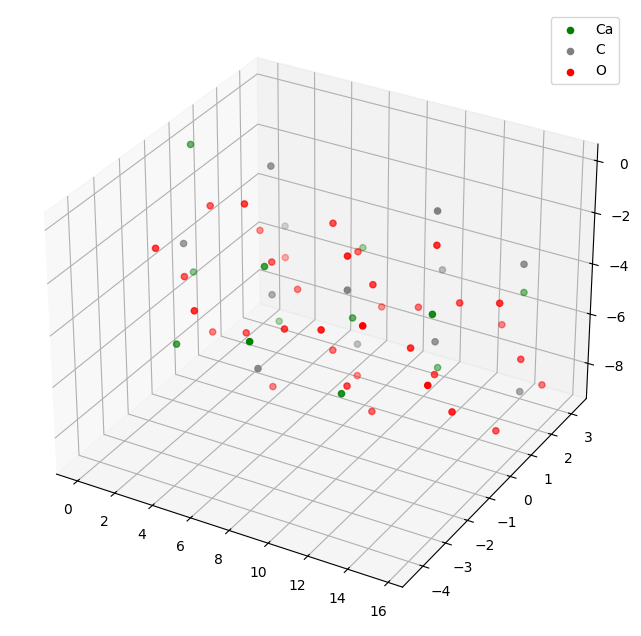

{'C', 'Ca', 'O'}

In [104]:
obj = supercell
coords = obj.cart_coords
species= [site.species_string for site in obj]
unique_species = set(species)
colors = {
        'Mg': 'blue', 'S': 'yellow', 'O': 'red', 
        'Ca': 'green', 'C': 'gray', 'Zn': 'orange',
        'Cd': 'brown'
    }
fig= plt.figure(figsize = (9,8))
ax = fig.add_subplot(111, projection = '3d')
for sp in unique_species:
    color = colors[sp]
    mask = np.array([s == sp for s in species])
    coords_sp = coords[mask]
    
    ax.scatter(coords_sp[:,0], coords_sp[:,1], coords_sp[:,2], s = 20, c = color, label = sp)

ax.legend()
plt.show()
unique_species

(<Figure size 1000x800 with 1 Axes>,
 <Axes3D: title={'center': 'Crystal Structure\n60 atoms'}, xlabel='X (Å)\na = 5.007 Å', ylabel='Y (Å)\nb = 8.672 Å', zlabel='Z (Å)\nc = 16.990 Å'>)

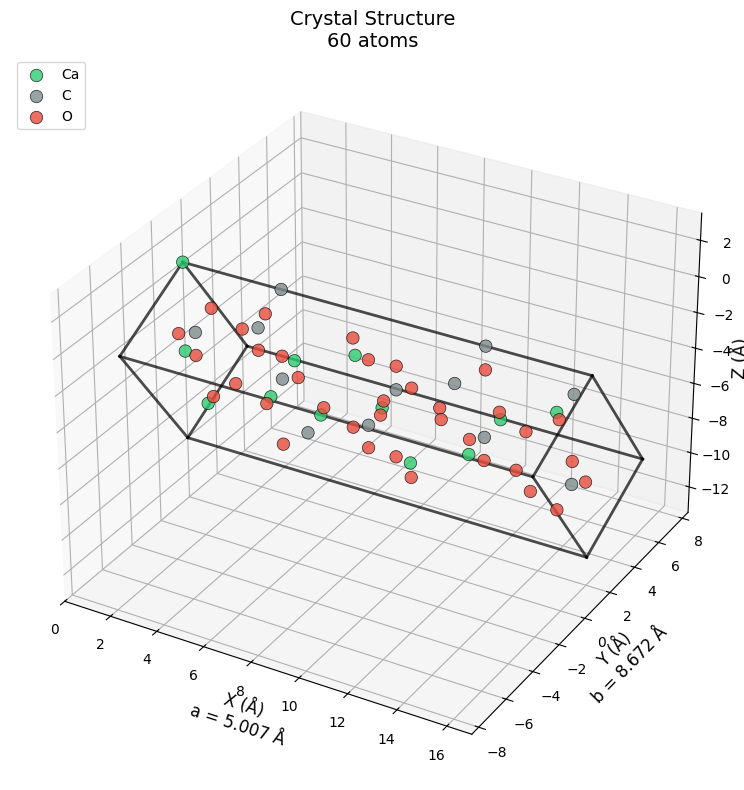

In [71]:
def plot_crystal_structure(structure: Structure, title: str = "Crystal Structure", 
                           figsize: tuple = (10, 8), show_labels: bool = True):
    """
    Визуализирует кристаллическую структуру в 3D с рёбрами элементарной ячейки.
    
    Параметры:
        structure: pymatgen Structure объект
        title: заголовок графика
        figsize: размер фигуры
        show_labels: показывать ли подписи атомов
    """
    from mpl_toolkits.mplot3d import Axes3D
    from mpl_toolkits.mplot3d.art3d import Poly3DCollection
    
    # Получаем координаты и типы атомов в ангстремах
    coords = structure.cart_coords
    species = [site.species_string for site in structure]
    
    # Словарь цветов для разных элементов
    colors = {
        'Mg': '#2E86C1',   # синий
        'S': '#F7DC6F',    # жёлтый
        'O': '#E74C3C',    # красный
        'Ca': '#2ECC71',   # зелёный
        'C': '#7F8C8D',    # серый
        'Zn': '#E67E22',   # оранжевый
        'Cd': '#8E44AD',   # фиолетовый
        'Ag': '#BDC3C7',   # серебряный
        'Ga': '#1ABC9C',   # бирюзовый
    }
    
    # Создаём фигуру
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')
    
    # Рисуем атомы
    unique_species = set(species)
    for sp in unique_species:
        color = colors.get(sp, '#95A5A6')
        mask = np.array([s == sp for s in species])
        coords_sp = coords[mask]
        ax.scatter(coords_sp[:, 0], coords_sp[:, 1], coords_sp[:, 2],
                   c=color, label=sp, s=80, alpha=0.8, edgecolors='black', linewidth=0.5)
    
    # --- РИСУЕМ РЁБРА ЯЧЕЙКИ ---
    lattice = structure.lattice.matrix
    origin = np.array([0, 0, 0])
    
    # Углы куба/параллелепипеда
    corners = np.array([
        origin,
        lattice[0],
        lattice[1],
        lattice[2],
        lattice[0] + lattice[1],
        lattice[0] + lattice[2],
        lattice[1] + lattice[2],
        lattice[0] + lattice[1] + lattice[2]
    ])
    
    # Определяем рёбра (пары индексов углов)
    edges = [
        [0, 1], [0, 2], [0, 3],  # из начала координат
        [1, 4], [1, 5],          # из вершины a
        [2, 4], [2, 6],          # из вершины b
        [3, 5], [3, 6],          # из вершины c
        [4, 7], [5, 7], [6, 7]   # к противоположной вершине
    ]
    
    # Рисуем рёбра
    for edge in edges:
        ax.plot3D(corners[edge, 0], corners[edge, 1], corners[edge, 2],
                  'k-', linewidth=2, alpha=0.7)
    
    # Добавляем подписи осей координат с размерами ячейки
    a_len = np.linalg.norm(lattice[0])
    b_len = np.linalg.norm(lattice[1])
    c_len = np.linalg.norm(lattice[2])
    
    ax.set_xlabel(f'X (Å)\na = {a_len:.3f} Å', fontsize=12)
    ax.set_ylabel(f'Y (Å)\nb = {b_len:.3f} Å', fontsize=12)
    ax.set_zlabel(f'Z (Å)\nc = {c_len:.3f} Å', fontsize=12)
    ax.set_title(f'{title}\n{len(structure)} atoms', fontsize=14)
    ax.legend(loc='upper left', fontsize=10)
    
    # Устанавливаем равные масштабы
    max_range = max(corners[:, 0].max() - corners[:, 0].min(),
                    corners[:, 1].max() - corners[:, 1].min(),
                    corners[:, 2].max() - corners[:, 2].min()) / 2
    mid_x = (corners[:, 0].max() + corners[:, 0].min()) / 2
    mid_y = (corners[:, 1].max() + corners[:, 1].min()) / 2
    mid_z = (corners[:, 2].max() + corners[:, 2].min()) / 2
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)
    
    plt.tight_layout()
    return fig, ax

plot_crystal_structure(obj)

### Нахождение n

In [120]:
q0 = q_ans
q0

array([ 1.30121390e-22-4.21298196e-25j,  4.64872321e-23-1.06012597e-25j,
       -9.79223662e-25+1.24157676e-24j, ...,
        6.88012214e-25+7.63813170e-25j,  2.53040429e-25+2.81045300e-25j,
       -7.60128976e-27-6.46652292e-27j], shape=(4800,))

[1.00000222+4.89572283e-12j 1.00000222-2.85937901e-11j
 1.00000222-3.71656867e-11j 1.00000222-6.03348931e-11j
 1.00000222-6.74504548e-11j 1.00000222-9.23188886e-11j
 1.00000222-1.04741308e-10j 1.00000222-1.29708030e-10j
 1.00000222-1.34942178e-10j 1.00000222-1.60163149e-10j
 1.00000222-1.64850639e-10j 1.00000222-1.97944936e-10j
 1.00000222-2.02786197e-10j 1.00000222-2.33132028e-10j
 1.00000222-2.34968487e-10j 1.00000222-2.59707638e-10j
 1.00000222-2.65946468e-10j 1.00000222-2.92307289e-10j
 1.00000222-3.03095693e-10j 1.00000222-3.32882652e-10j
 1.00000222-3.39168256e-10j 1.00000222-3.68910074e-10j
 1.00000222-3.69085402e-10j 1.00000222-3.95412106e-10j
 1.00000222-3.97978417e-10j 1.00000222-4.22474323e-10j
 1.00000222-4.30343969e-10j 1.00000222-4.60599042e-10j
 1.00000222-4.67644358e-10j 1.00000222-5.02704492e-10j
 1.00000222-5.10361085e-10j 1.00000222-5.38858696e-10j
 1.00000222-5.46078472e-10j 1.00000222-5.72812434e-10j
 1.00000222-5.71677725e-10j 1.00000222-5.97123599e-10j
 1.0000022

C:\Users\Егор\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\Егор\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


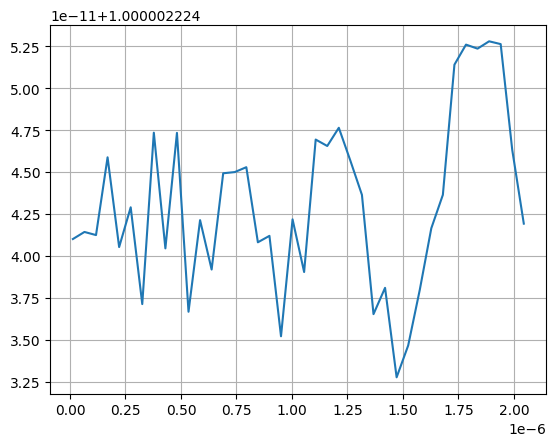

In [40]:
### только для изотропных, где по оси x
def n_def(q_vec, z_all, V_cell, N, E0 = 0.03, omega = 9e17, idx = 0):
    z = z_all.reshape((8,N))
    z_mean = np.mean(z, axis = 0)
    q_atoms = q_vec.reshape((8, N, 3))
    n_np = np.zeros(N, dtype = np.complex128)
    P_np = np.sum(q_atoms, axis = 0) / V_cell / 8
    n_np = np.sqrt(1 + 4 * np.pi * P_np[:, idx] / E0 / np.exp(- 1j * omega * z_mean / c))
    return n_np, z_mean

n_np, z_mean = n_def(q_ans, z_all, V_cell, N)
print(n_np)
plt.plot(z_mean, n_np)
plt.grid()

In [114]:
q_ans[:20]

array([ 1.30121390e-22-4.21298196e-25j,  4.64872321e-23-1.06012597e-25j,
       -9.79223662e-25+1.24157676e-24j,  3.10663980e-24-1.30779434e-22j,
        1.10955745e-24-4.67066711e-23j,  2.42175593e-24-8.83463406e-27j,
       -1.30050555e-22-6.39387961e-24j, -4.64450051e-23-2.28529001e-24j,
        9.66050385e-26-2.47154391e-24j, -9.39749111e-24+1.29996352e-22j,
       -3.35454277e-24+4.64266351e-23j, -2.47458905e-24-1.61744252e-25j,
        1.29442837e-22+1.21080057e-23j,  4.62294149e-23+4.32529506e-24j,
       -2.41123972e-25+2.46922376e-24j,  1.52650311e-23-1.29878844e-22j,
        5.45131952e-24-4.63854369e-23j,  2.43377560e-24+2.96993885e-25j,
       -1.29116106e-22-1.86666214e-23j, -4.61117081e-23-6.66873049e-24j])

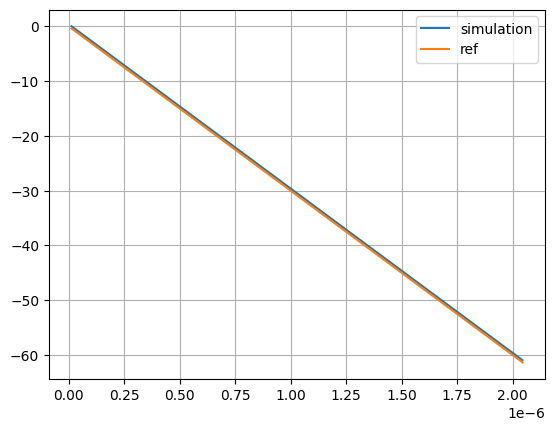

In [42]:
def phase_calc(q_vec, z_all, N, omega, idx = 0):
    z = z_all.reshape((8,N))
    z_mean = np.mean(z, axis = 0)
    q_atoms = q_vec.reshape((8, N, 3))
    q1 = q_atoms[0,:,idx]
    phase = np.angle(q1)
    phase_unwrapped = np.unwrap(phase)
    
    return phase_unwrapped, z_mean, phase

phase_np, z_mean, phases = phase_calc(q_ans, z_all, N, omega, idx = 0)
plt.plot(z_mean, phase_np, label = 'simulation')
ref_np = -omega / c * z_mean

plt.plot(z_mean, ref_np, label = 'ref')
plt.grid()
plt.legend()
plt.show()